In [5]:
import pandas as pd
import numpy as np
from nilearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
abide = datasets.fetch_abide_pcp(
    data_dir = "./ABIDE",
    derivatives = ['rois_aal'],
    quality_checked = True,
    pipeline = 'cpac'
)

[fetch_abide_pcp] Dataset found in ABIDE/ABIDE_pcp


In [7]:
pheno = abide.phenotypic
time_series = abide.rois_aal

print(pheno.shape)
print(len(time_series))

(871, 106)
871


In [8]:
time_series[0].shape

(196, 116)

In [21]:
# Descriptive stats by site
df = pheno.copy()

df_right = df[(df['HANDEDNESS_CATEGORY'] == 'R')]

site_stats = df.groupby('SITE_ID').agg({
    'SUB_ID': 'count',
    'DX_GROUP': lambda x: x.value_counts().to_dict(),
    'SEX': lambda x: x.value_counts().to_dict(),
    'HANDEDNESS_CATEGORY': lambda x: x.value_counts().to_dict(),
    'AGE_AT_SCAN': ['mean', 'std', 'min', 'max']
}).round(2)

# Calculate balance metric for DX_GROUP
site_stats['dx_balance'] = df_right.groupby('SITE_ID')['DX_GROUP'].apply(
    lambda x: min(x.value_counts()) / max(x.value_counts()) if len(x.value_counts()) > 1 else 1.0
)

# Calculate age std as a metric
site_stats['age_std'] = df_right.groupby('SITE_ID')['AGE_AT_SCAN'].std()

# Sort by DX_GROUP balance (descending) and then by age_std (ascending)
site_stats = site_stats.sort_values(by=['dx_balance', 'age_std'], ascending=[False, True])

print("Site Statistics:\n")
# Descriptive stats by site
df_right = df[(df['HANDEDNESS_CATEGORY'] == 'R')]

site_stats = df.groupby('SITE_ID').agg({
    'SUB_ID': 'count',
    'DX_GROUP': lambda x: x.value_counts().to_dict(),
    'SEX': lambda x: x.value_counts().to_dict(),
    'HANDEDNESS_CATEGORY': lambda x: x.value_counts().to_dict(),
    'AGE_AT_SCAN': ['mean', 'std', 'min', 'max']
}).round(2)

# Calculate balance metric for DX_GROUP
site_stats['dx_balance'] = df_right.groupby('SITE_ID')['DX_GROUP'].apply(
    lambda x: min(x.value_counts()) / max(x.value_counts()) if len(x.value_counts()) > 1 else 1.0
)

# Calculate age std as a metric
site_stats['age_std'] = df_right.groupby('SITE_ID')['AGE_AT_SCAN'].std()

# Sort by DX_GROUP balance (descending) and then by age_std (ascending)
site_stats = site_stats.sort_values(by=['dx_balance', 'age_std'], ascending=[False, True])

site_stats

Site Statistics:



SUB_ID        DX_GROUP              SEX  \
          count        <lambda>         <lambda>   
SITE_ID                                            
YALE         41  {1: 22, 2: 19}   {1: 25, 2: 16}   
LEUVEN_1     28  {2: 14, 1: 14}          {1: 28}   
CMU          11    {1: 6, 2: 5}     {1: 7, 2: 4}   
OLIN         28  {2: 14, 1: 14}    {1: 23, 2: 5}   
PITT         50  {2: 26, 1: 24}    {1: 43, 2: 7}   
OHSU         25  {2: 13, 1: 12}          {1: 25}   
UCLA_2       21  {1: 11, 2: 10}    {1: 19, 2: 2}   
LEUVEN_2     28  {2: 16, 1: 12}    {1: 21, 2: 7}   
TRINITY      44  {2: 25, 1: 19}          {1: 44}   
UCLA_1       64  {1: 37, 2: 27}    {1: 55, 2: 9}   
STANFORD     25  {2: 13, 1: 12}    {1: 18, 2: 7}   
MAX_MUN      46  {2: 27, 1: 19}    {1: 42, 2: 4}   
UM_1         86  {2: 52, 1: 34}   {1: 61, 2: 25}   
UM_2         34  {2: 21, 1: 13}    {1: 32, 2: 2}   
KKI          33  {2: 21, 1: 12}    {1: 24, 2: 9}   
SDSU         27   {2: 19, 1: 8}    {1: 21, 2: 6}   
CALTECH      15   {2: 10, 1: 5}    {1: 10, 2: 5}   
NYU         172  {2: 98, 1: 74}  {1: 136, 2: 36}   
SBL          26  {2: 14, 1: 12}          {1: 26}   
USM          67  {1: 43, 2: 24}          {1: 67}   

                     HANDEDNESS_CATEGORY AGE_AT_SCAN                       \
                                <lambda>        mean    std    min    max   
SITE_ID                                                                     
YALE                   {'R': 34, 'L': 7}       13.31   2.64   7.00  17.75   
LEUVEN_1               {'R': 26, 'L': 2}       22.43   3.51  18.00  32.00   
CMU                    {'R': 10, 'L': 1}       26.82   4.81  19.00  33.00   
OLIN                   {'R': 23, 'L': 5}       17.04   3.43  10.00  24.00   
PITT       {'R': 45, 'L': 4, '-9999': 1}       18.50   6.76   9.33  35.20   
OHSU                   {'R': 24, 'L': 1}       10.81   1.75   8.00  15.23   
UCLA_2                 {'R': 18, 'L': 3}       12.47   1.67   9.79  16.47   
LEUVEN_2               {'R': 23, 'L': 5}       14.17   1.48  12.10  16.90   
TRINITY                        {'R': 44}       17.03   3.50  12.00  25.66   
UCLA_1                 {'R': 58, 'L': 6}       13.35   2.38   8.36  17.94   
STANFORD    {'R': 20, 'L': 3, 'Ambi': 2}        9.99   1.63   7.53  12.94   
MAX_MUN                {'R': 44, 'L': 2}       26.50  10.63   7.00  58.00   
UM_1      {'R': 67, 'L': 12, '-9999': 6}       13.77   2.96   8.20  19.20   
UM_2       {'R': 30, 'L': 3, '-9999': 1}       16.01   3.36  12.80  28.80   
KKI        {'R': 27, 'Mixed': 5, 'L': 1}       10.31   1.28   8.20  12.77   
SDSU                   {'R': 25, 'L': 2}       14.36   1.93   8.67  17.15   
CALTECH     {'R': 13, 'Ambi': 1, 'L': 1}       26.79  10.77  17.00  56.20   
NYU                                   {}       15.33   6.60   6.47  39.10   
SBL                             {'L': 1}       33.77   6.60  20.00  49.00   
USM                                   {}       22.59   8.36   8.77  50.22   

         dx_balance    age_std  
                                
SITE_ID                         
YALE       1.000000   2.576425  
LEUVEN_1   1.000000   3.646073  
CMU        1.000000   4.976612  
OLIN       0.916667   3.158526  
PITT       0.875000   6.518145  
OHSU       0.846154   1.656847  
UCLA_2     0.800000   1.607001  
LEUVEN_2   0.769231   1.615109  
TRINITY    0.760000   3.499596  
UCLA_1     0.705882   2.334926  
STANFORD   0.666667   1.681416  
MAX_MUN    0.629630  10.834426  
UM_1       0.595238   2.905917  
UM_2       0.578947   3.482462  
KKI        0.500000   1.282106  
SDSU       0.470588   1.966193  
CALTECH    0.444444  11.436816  
NYU             NaN        NaN  
SBL             NaN        NaN  
USM             NaN        NaN

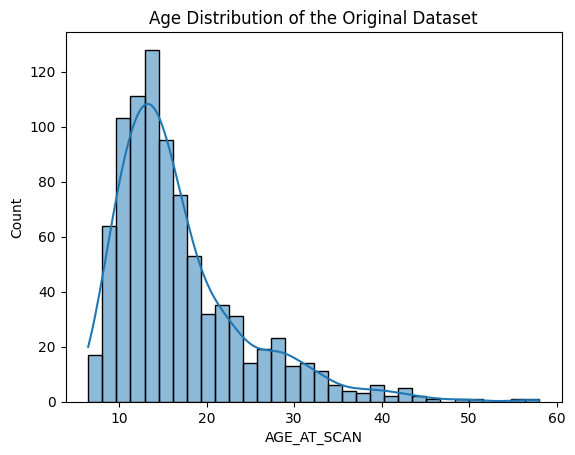

<Figure size 640x480 with 0 Axes>

In [10]:
sns.histplot(pheno['AGE_AT_SCAN'], kde = True)
plt.title("Age Distribution of the Original Dataset")
plt.show()
plt.savefig("./Results/Age_Dist_Original")

In [ ]:
young = pheno[(pheno['AGE_AT_SCAN'] > 6) & (pheno['AGE_AT_SCAN'] <= 25)]
young_ids = young['SUB_ID'].to_list()

with open("Young_IDs", "wb") as fp:
    pickle.dump(young_ids, fp)

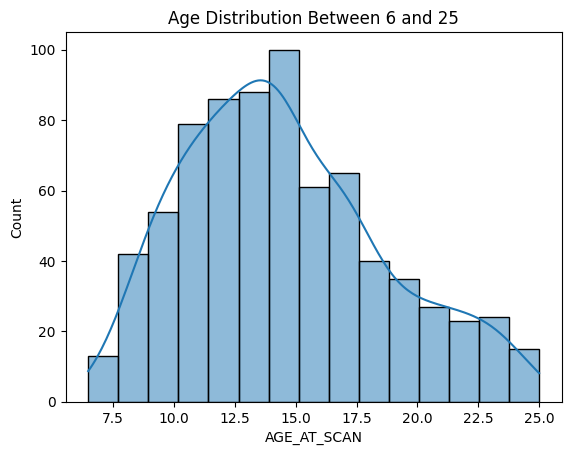

<Figure size 640x480 with 0 Axes>

In [12]:
sns.histplot(young['AGE_AT_SCAN'], kde = True)
plt.title("Age Distribution Between 6 and 25")
plt.show()
plt.savefig("./Results/Age_Dist_Filtered")

In [13]:
young.groupby(['SEX', 'DX_GROUP'])['SUB_ID'].count()

SEX  DX_GROUP
1    1           298
     2           323
2    1            48
     2            83
Name: SUB_ID, dtype: int64

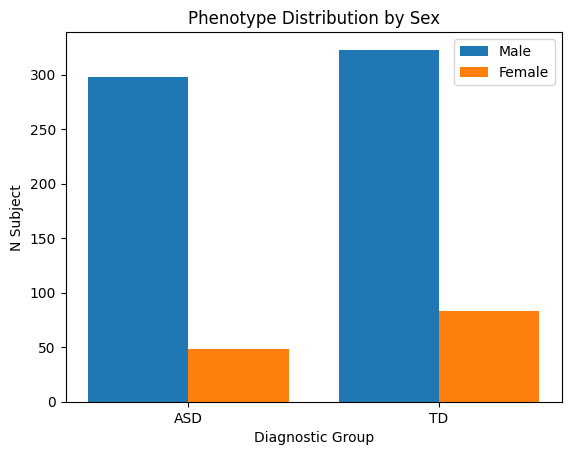

<Figure size 640x480 with 0 Axes>

In [15]:
x = np.arange(2)
y1 = [298, 323]
y2 = [48, 83]
width = 0.4

plt.bar(x-0.2, y1, width)
plt.bar(x+0.2, y2, width)

plt.xticks(x, ['ASD', 'TD'])
plt.xlabel('Diagnostic Group')
plt.ylabel('N Subject')
plt.legend(['Male', 'Female'])

plt.title('Phenotype Distribution by Sex')

plt.show()
plt.savefig("./Results/Pheno_Dist_by_Sex")